## Task 0
  Load the raw CIFAR-10 training and test sets and display 8 sample images in a grid so
you can observe the original 32×32 resolution. Then, look up transforms.Resize in the
torchvision documentation and in a markdown cell briefly describe the default interpola-
tion method used and why it may or may not be well-suited for upscaling small images.
Finally, apply the full preprocessing pipeline required for compatibility with a pretrained
ResNet — resizing to 224 × 224, converting to tensor, and normalizing with ImageNet
channel-wise mean [0.485, 0.456, 0.406] and standard deviation [0.229, 0.224, 0.225] — and
display the same 8 samples after resizing (but before normalization, so colors remain in-
terpretable) to observe the effect of upscaling.


Given that bilinear interpolation introduces blurring when upscaling 32×32 images to
224×224, do you expect this to help or hurt the pretrained ResNet’s ability to extract
meaningful features? Would a model trained on sharp, high-resolution ImageNet pho-
tographs be well-calibrated for blurry, upscaled inputs?

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load raw CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
x_train: (50000, 32, 32, 3)
y_train: (50000, 1)
x_test: (10000, 32, 32, 3)
y_test: (10000, 1)


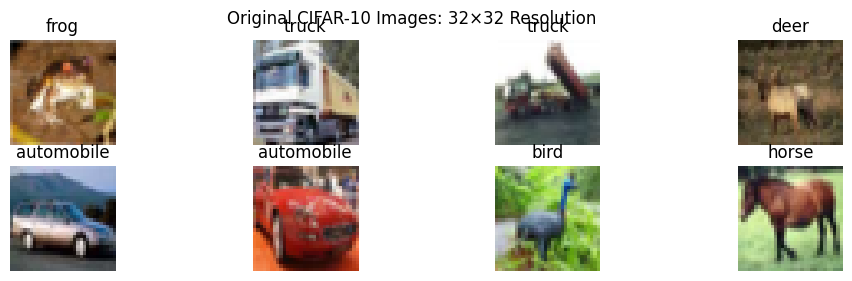

In [2]:
import matplotlib.pyplot as plt

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

sample_idx = list(range(8))

plt.figure(figsize=(12, 3))

for plot_i, idx in enumerate(sample_idx):
    plt.subplot(2, 4, plot_i + 1)
    plt.imshow(x_train[idx])
    plt.title(class_names[y_train[idx][0]])
    plt.axis("off")

plt.suptitle("Original CIFAR-10 Images: 32×32 Resolution")
plt.show()

According to the torchvision documentation, `transforms.Resize` uses `InterpolationMode.BILINEAR` by default. Bilinear interpolation estimates new pixel values using nearby pixels, which usually gives smoother results than nearest-neighbor interpolation.

For CIFAR-10, the original images are only 32×32 pixels, so resizing them to 224×224 greatly upscales the image. Bilinear interpolation is reasonable because it avoids blocky artifacts, but it cannot create new real detail. As a result, the resized images may look blurry or artificially smoothed, which may limit how well a pretrained ResNet can use the upscaled images.

### Apply ResNet preprocessing pipeline

x norm =  (x - mean) / std




In [3]:
import torch
from torchvision import transforms
from PIL import Image

# Full preprocessing for pretrained ResNet
resnet_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Separate resize-only transform for visualization before normalization
resize_only = transforms.Compose([
    transforms.Resize((224, 224))
])

### Display same 8 images after resizing, before normalization

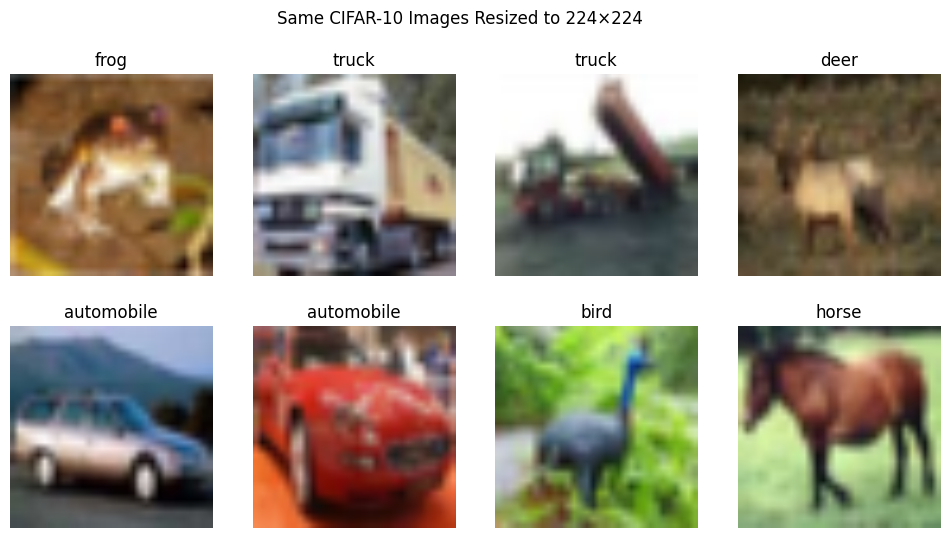

In [4]:
plt.figure(figsize=(12, 6))

for plot_i, idx in enumerate(sample_idx):
    img = Image.fromarray(x_train[idx])
    resized_img = resize_only(img)

    plt.subplot(2, 4, plot_i + 1)
    plt.imshow(resized_img)
    plt.title(class_names[y_train[idx][0]])
    plt.axis("off")

plt.suptitle("Same CIFAR-10 Images Resized to 224×224")
plt.show()

### Example: create normalized tensors for ResNet

In [5]:
processed_samples = []

for idx in sample_idx:
    img = Image.fromarray(x_train[idx])
    tensor = resnet_preprocess(img)
    processed_samples.append(tensor)

processed_samples = torch.stack(processed_samples)

print(processed_samples.shape)

torch.Size([8, 3, 224, 224])


Bilinear interpolation introduces a distribution shift by smoothing high-frequency details. Since pretrained ResNet models rely on such details learned from ImageNet, this mismatch can reduce feature quality, though coarse semantic information remains usable

# Task 1
Create training and test DataLoader objects for the preprocessed CIFAR-10 datasets
using a batch size of 256. Explain in a comment why the training loader shuffles the
data but the test loader does not

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

# ResNet preprocessing pipeline
resnet_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
class CIFAR10ArrayDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx])
        label = int(self.labels[idx][0])

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
train_dataset = CIFAR10ArrayDataset(
    x_train,
    y_train,
    transform=resnet_preprocess
)

test_dataset = CIFAR10ArrayDataset(
    x_test,
    y_test,
    transform=resnet_preprocess
)

In [9]:
batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
    # Shuffle training data so the model sees classes/images in random order each epoch,
    # which improves generalization and avoids learning order-based patterns.
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
    # Do not shuffle test data because evaluation does not update the model,
    # and keeping a fixed order makes results reproducible and easier to compare.
)

In [10]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([256, 3, 224, 224])
torch.Size([256])


Shuffle training data so the model sees classes/images in random order each epoch, which improves generalization and avoids learning order-based patterns.


Do not shuffle test data because evaluation does not update the model, and keeping a fixed order makes results reproducible and easier to compare.

### Task 2

Load a ResNet-18 model pretrained on ImageNet using torchvision.models. Print the
full architecture and inspect the final layer — identify its input size, output size, and
explain why the default output is incompatible with CIFAR-10

In [11]:
import torchvision.models as models

# Load ResNet-18 pretrained on ImageNet
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Print full architecture
print(resnet18)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 125MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
print(resnet18.fc)

Linear(in_features=512, out_features=1000, bias=True)


In [13]:
import torch.nn as nn

resnet18.fc = nn.Linear(in_features=512, out_features=10)

print(resnet18.fc)

Linear(in_features=512, out_features=10, bias=True)


The final layer of pretrained ResNet-18 is a fully connected layer:

`Linear(in_features=512, out_features=1000)`

The input size is 512 because ResNet-18 produces a 512-dimensional feature vector before classification.

The output size is 1000 because the model was pretrained on ImageNet, which has 1000 classes.

This is incompatible with CIFAR-10 because CIFAR-10 has only 10 classes. Therefore, the final layer must be replaced with a new linear layer that outputs 10 logits instead of 1000.

### Task 3

Replace the final fully connected layer of ResNet-18 with a new one that outputs 10
classes instead of 1,000. Then freeze all other layers so that only the new head will
be trained, preserving the pretrained ImageNet representations. Verify your setup by
printing the number of trainable vs. total parameters.

In [15]:
import torch.nn as nn

# Freeze all pretrained layers
for param in resnet18.parameters():
    param.requires_grad = False

# Replace final fully connected layer for CIFAR-10
resnet18.fc = nn.Linear(
    in_features=resnet18.fc.in_features,
    out_features=10
)

# The new fc layer is trainable by default
print(resnet18.fc)

Linear(in_features=512, out_features=10, bias=True)


In [16]:
trainable_params = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in resnet18.parameters())

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")
print(f"Percentage trainable: {100 * trainable_params / total_params:.4f}%")

Trainable parameters: 5,130
Total parameters: 11,181,642
Percentage trainable: 0.0459%


In [17]:
512 * 10 + 10

5130

# Task 4

Train the frozen ResNet-18 on CIFAR-10 for 10 epochs, recording training loss and test
accuracy after each epoch. Plot both curves. Then interpret what you observe - comment
on the rate of convergence, the final accuracy level, and what the shape of the curves
suggests about whether the frozen features are well-suited to CIFAR-10

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

resnet18 = resnet18.to(device)

criterion = nn.CrossEntropyLoss()

# Only train the new final layer
optimizer = optim.Adam(resnet18.fc.parameters(), lr=0.001)

num_epochs = 10

train_losses = []
test_accuracies = []

Using device: cuda


In [19]:
for epoch in range(num_epochs):
    # Training
    resnet18.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = resnet18(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Evaluation
    resnet18.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet18(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy = correct / total
    test_accuracies.append(test_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {epoch_train_loss:.4f} "
        f"Test Accuracy: {test_accuracy:.4f}"
    )

Epoch [1/10] Train Loss: 1.0248 Test Accuracy: 0.7685
Epoch [2/10] Train Loss: 0.6549 Test Accuracy: 0.7906
Epoch [3/10] Train Loss: 0.6028 Test Accuracy: 0.7957
Epoch [4/10] Train Loss: 0.5780 Test Accuracy: 0.8003
Epoch [5/10] Train Loss: 0.5590 Test Accuracy: 0.7955
Epoch [6/10] Train Loss: 0.5510 Test Accuracy: 0.8059
Epoch [7/10] Train Loss: 0.5446 Test Accuracy: 0.8042
Epoch [8/10] Train Loss: 0.5393 Test Accuracy: 0.8021
Epoch [9/10] Train Loss: 0.5325 Test Accuracy: 0.8079
Epoch [10/10] Train Loss: 0.5277 Test Accuracy: 0.8062


### Plot training loss

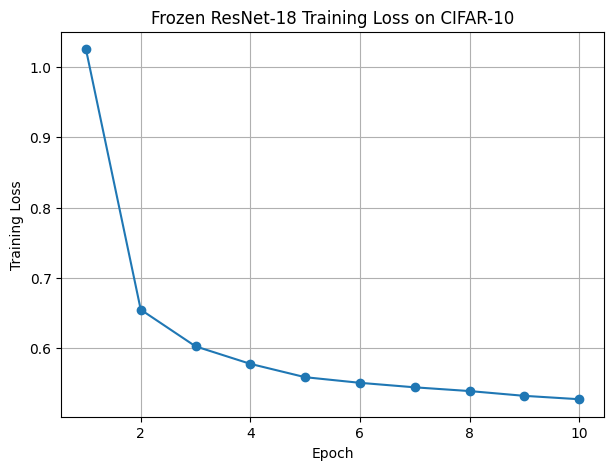

In [20]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Frozen ResNet-18 Training Loss on CIFAR-10")
plt.grid(True)
plt.show()

### Plot test accuracy

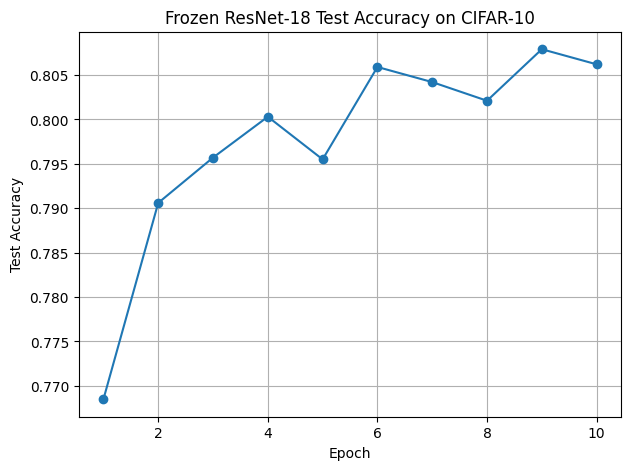

In [21]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, num_epochs + 1), test_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Frozen ResNet-18 Test Accuracy on CIFAR-10")
plt.grid(True)
plt.show()

The frozen ResNet-18 converges relatively quickly because only the final fully connected classification head is being trained. The pretrained convolutional layers are fixed, so the model does not need to learn low-level visual features from scratch.

The training loss should decrease most rapidly during the first few epochs and then begin to flatten. Similarly, test accuracy should improve early and then plateau. This plateau suggests that the frozen ImageNet features provide useful general visual representations, but they are not perfectly matched to CIFAR-10.

The final accuracy is expected to be reasonable but limited. CIFAR-10 images are originally 32×32 and must be upscaled to 224×224 for ResNet-18, which introduces blurring and creates a distribution mismatch compared with sharp ImageNet images. Therefore, the frozen features are helpful for extracting general patterns such as shapes and edges, but they may not be fully well-suited for the small, blurry, upscaled CIFAR-10 inputs.

In [22]:
for name, param in resnet18.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

fc.weight torch.Size([10, 512])
fc.bias torch.Size([10])


# Task 5

Sample one image per class from the test set and run inference with the trained model.
Display the class probabilities for each sample in a table (one row per true class, one
column per label, plus an argmax prediction column). Then plot all 10 images in a 2×5
grid, annotating each with the true label and the model’s prediction.

In [23]:
import pandas as pd
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

# One test image per class
selected_indices = {}

for idx in range(len(y_test)):
    label = int(y_test[idx][0])
    if label not in selected_indices:
        selected_indices[label] = idx
    if len(selected_indices) == 10:
        break

selected_indices = [selected_indices[i] for i in range(10)]

In [24]:
resnet18.eval()

prob_rows = []
original_images = []
true_labels = []
pred_labels = []

with torch.no_grad():
    for idx in selected_indices:
        true_label = int(y_test[idx][0])
        img_np = x_test[idx]
        img_pil = Image.fromarray(img_np)

        input_tensor = resnet_preprocess(img_pil).unsqueeze(0).to(device)

        logits = resnet18(input_tensor)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

        pred_label = int(np.argmax(probs))

        row = {
            "true_class": class_names[true_label],
            "prediction": class_names[pred_label]
        }

        for i, class_name in enumerate(class_names):
            row[class_name] = probs[i]

        prob_rows.append(row)
        original_images.append(img_np)
        true_labels.append(true_label)
        pred_labels.append(pred_label)

In [25]:
prob_table = pd.DataFrame(prob_rows)

prob_table

,true_class,prediction,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
0,airplane,airplane,5.698415e-01,6.125377e-03,0.094592,0.148283,5.005022e-03,0.002625,0.026527,3.784281e-03,1.178964e-01,2.532083e-02
1,automobile,truck,2.092450e-02,2.405481e-01,0.000334,0.036965,4.892450e-04,0.070585,0.001106,1.384090e-02,7.511733e-04,6.144557e-01
2,bird,dog,9.859602e-04,3.307614e-05,0.059290,0.289831,1.136166e-01,0.427133,0.046033,6.291778e-02,1.401863e-04,1.821940e-05
3,cat,cat,1.776993e-04,9.003359e-05,0.000454,0.832542,8.523031e-05,0.166082,0.000455,5.528035e-05,2.790774e-05,3.090080e-05
4,deer,deer,7.626482e-03,2.190380e-03,0.008508,0.070716,7.639309e-01,0.055620,0.004714,6.736928e-04,8.572537e-02,2.942220e-04
5,dog,dog,1.864165e-04,1.571625e-05,0.066660,0.056493,1.776199e-02,0.829392,0.013753,1.555061e-02,9.652963e-05,9.075750e-05
6,frog,frog,1.158013e-07,3.532652e-08,0.001142,0.000058,2.656025e-04,0.000002,0.998531,8.597669e-08,5.191062e-08,1.414093e-09
7,horse,horse,1.683611e-03,2.168826e-02,0.001768,0.220146,3.199171e-02,0.288900,0.015362,3.191282e-01,1.685342e-04,9.916348e-02
8,ship,ship,4.215224e-02,8.370966e-03,0.003139,0.002299,5.334936e-05,0.000945,0.000081,2.653118e-04,9.426817e-01,1.290928e-05
9,truck,truck,2.675577e-06,9.190841e-04,0.000001,0.000024,6.851035e-07,0.000014,0.000006,4.106524e-07,2.546910e-05,9.990060e-01


In [26]:
prob_table_rounded = prob_table.copy()

for class_name in class_names:
    prob_table_rounded[class_name] = prob_table_rounded[class_name].round(4)

prob_table_rounded

,true_class,prediction,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
0,airplane,airplane,0.5698,0.0061,0.0946,0.1483,0.0050,0.0026,0.0265,0.0038,0.1179,0.0253
1,automobile,truck,0.0209,0.2405,0.0003,0.0370,0.0005,0.0706,0.0011,0.0138,0.0008,0.6145
2,bird,dog,0.0010,0.0000,0.0593,0.2898,0.1136,0.4271,0.0460,0.0629,0.0001,0.0000
3,cat,cat,0.0002,0.0001,0.0005,0.8325,0.0001,0.1661,0.0005,0.0001,0.0000,0.0000
4,deer,deer,0.0076,0.0022,0.0085,0.0707,0.7639,0.0556,0.0047,0.0007,0.0857,0.0003
5,dog,dog,0.0002,0.0000,0.0667,0.0565,0.0178,0.8294,0.0138,0.0156,0.0001,0.0001
6,frog,frog,0.0000,0.0000,0.0011,0.0001,0.0003,0.0000,0.9985,0.0000,0.0000,0.0000
7,horse,horse,0.0017,0.0217,0.0018,0.2201,0.0320,0.2889,0.0154,0.3191,0.0002,0.0992
8,ship,ship,0.0422,0.0084,0.0031,0.0023,0.0001,0.0009,0.0001,0.0003,0.9427,0.0000
9,truck,truck,0.0000,0.0009,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.9990


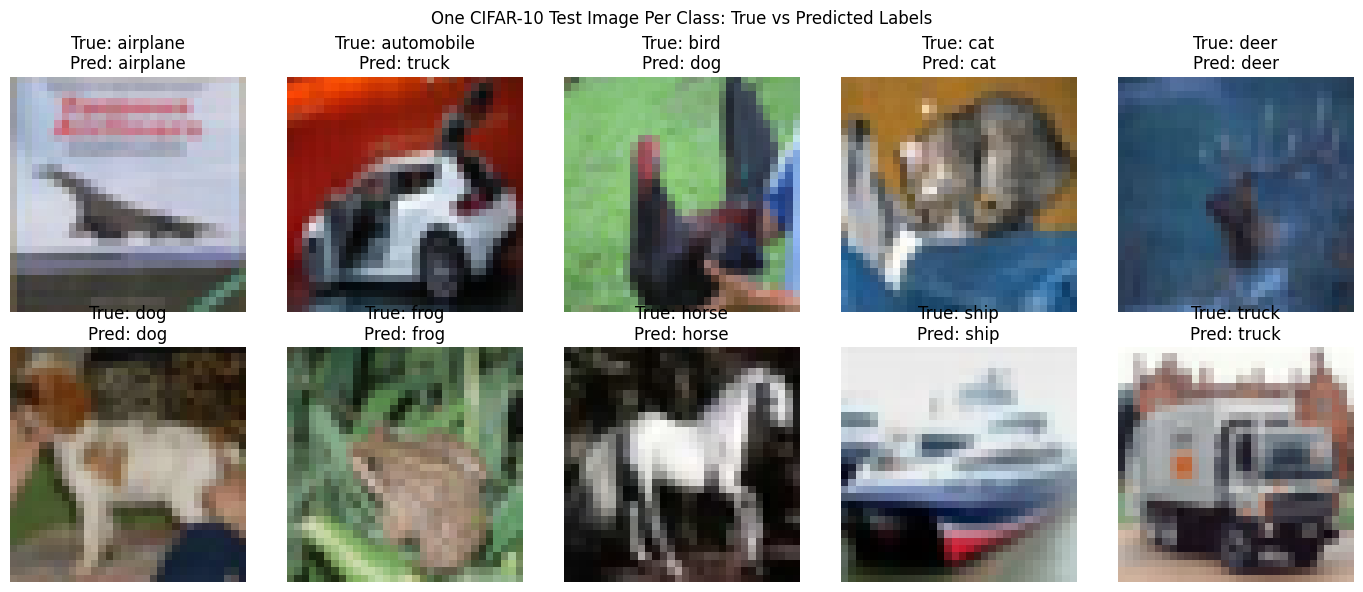

In [27]:
plt.figure(figsize=(14, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(original_images[i])
    plt.axis("off")

    true_name = class_names[true_labels[i]]
    pred_name = class_names[pred_labels[i]]

    plt.title(f"True: {true_name}\nPred: {pred_name}")

plt.suptitle("One CIFAR-10 Test Image Per Class: True vs Predicted Labels")
plt.tight_layout()
plt.show()

# Task 6

Unfreeze the last residual block (layer4) along with the classification head, and fine-tune
for 10 epochs using a smaller learning rate. This is the most common partial fine-tuning
strategy — early layers capture general low-level features (edges, textures) that transfer
well across datasets, while later layers capture more task-specific features that benefit
from adaptation to CIFAR-10

In [28]:
# Freeze everything first
for param in resnet18.parameters():
    param.requires_grad = False

# Unfreeze last residual block
for param in resnet18.layer4.parameters():
    param.requires_grad = True

# Unfreeze classification head
for param in resnet18.fc.parameters():
    param.requires_grad = True

In [29]:
for name, param in resnet18.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

layer4.0.conv1.weight torch.Size([512, 256, 3, 3])
layer4.0.bn1.weight torch.Size([512])
layer4.0.bn1.bias torch.Size([512])
layer4.0.conv2.weight torch.Size([512, 512, 3, 3])
layer4.0.bn2.weight torch.Size([512])
layer4.0.bn2.bias torch.Size([512])
layer4.0.downsample.0.weight torch.Size([512, 256, 1, 1])
layer4.0.downsample.1.weight torch.Size([512])
layer4.0.downsample.1.bias torch.Size([512])
layer4.1.conv1.weight torch.Size([512, 512, 3, 3])
layer4.1.bn1.weight torch.Size([512])
layer4.1.bn1.bias torch.Size([512])
layer4.1.conv2.weight torch.Size([512, 512, 3, 3])
layer4.1.bn2.weight torch.Size([512])
layer4.1.bn2.bias torch.Size([512])
fc.weight torch.Size([10, 512])
fc.bias torch.Size([10])


In [32]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, resnet18.parameters()),
    lr=1e-4
)

num_epochs = 10

ft_train_losses = []
ft_test_accuracies = []

In [33]:
for epoch in range(num_epochs):
    resnet18.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = resnet18(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    ft_train_losses.append(epoch_loss)

    resnet18.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet18(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = correct / total
    ft_test_accuracies.append(test_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {epoch_loss:.4f} "
        f"Test Accuracy: {test_acc:.4f}"
    )

Epoch [1/10] Train Loss: 0.3696 Test Accuracy: 0.8848
Epoch [2/10] Train Loss: 0.1063 Test Accuracy: 0.8952
Epoch [3/10] Train Loss: 0.0305 Test Accuracy: 0.9011
Epoch [4/10] Train Loss: 0.0098 Test Accuracy: 0.9048
Epoch [5/10] Train Loss: 0.0044 Test Accuracy: 0.9063
Epoch [6/10] Train Loss: 0.0025 Test Accuracy: 0.9056
Epoch [7/10] Train Loss: 0.0017 Test Accuracy: 0.9075
Epoch [8/10] Train Loss: 0.0013 Test Accuracy: 0.9060
Epoch [9/10] Train Loss: 0.0010 Test Accuracy: 0.9066
Epoch [10/10] Train Loss: 0.0008 Test Accuracy: 0.9058


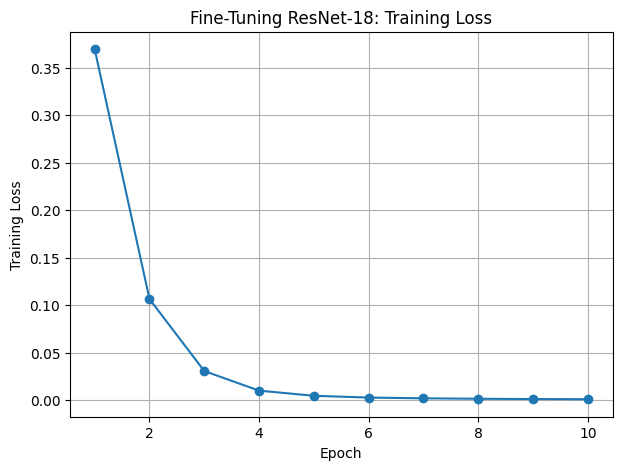

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(range(1, num_epochs + 1), ft_train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Fine-Tuning ResNet-18: Training Loss")
plt.grid(True)
plt.show()

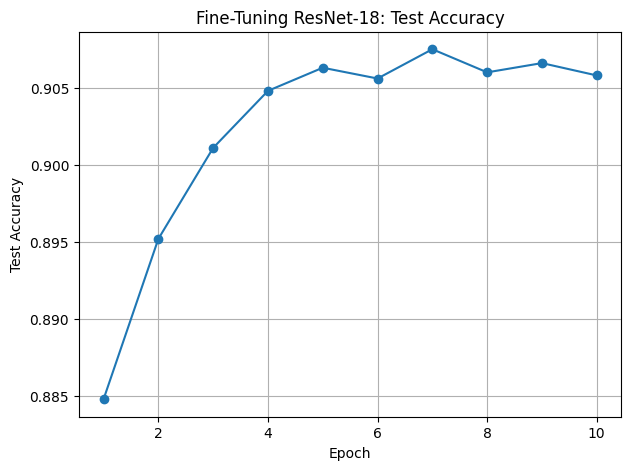

In [35]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, num_epochs + 1), ft_test_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Fine-Tuning ResNet-18: Test Accuracy")
plt.grid(True)
plt.show()

In [36]:
trainable_params = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in resnet18.parameters())

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")
print(f"Percentage trainable: {100 * trainable_params / total_params:.2f}%")

Trainable parameters: 8,398,858
Total parameters: 11,181,642
Percentage trainable: 75.11%


In [40]:
from datetime import datetime
print(datetime.now())

2026-04-26 07:07:03.789162


In this step, we unfreeze `layer4` and the final classification head while keeping the earlier ResNet layers frozen. This is a common partial fine-tuning strategy because early convolutional layers usually learn general visual patterns such as edges, colors, and textures, which transfer well across datasets. Later layers learn more task-specific semantic features, so allowing `layer4` to update helps the model adapt ImageNet representations to CIFAR-10.

A smaller learning rate is used because the model already contains useful pretrained weights. Large updates could destroy these pretrained representations, while a smaller learning rate allows gradual adaptation.

# Summary

ResNet pretrained on ImageNet provides strong general visual features. Training only the classification head converges quickly but is limited by feature mismatch. Partial fine-tuning improves performance by adapting higher-level representations to CIFAR-10, while preserving general low-level features learned from ImageNet.

In [41]:
torch.save(resnet18.state_dict(), "resnet18_cifar10.pth")